In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"D:\metropt+3+dataset\MetroPT3(AirCompressor).csv"

df = pd.read_csv(file_path)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Dataset shape: (1516948, 17)
Start: 2020-02-01 00:00:00
End: 2020-09-01 03:59:50


In [2]:
failure_periods = [
    {
        "failure_id": 1,
        "start": "2020-04-18 00:00:00",
        "end": "2020-04-18 23:59:00"
    },
    {
        "failure_id": 2,
        "start": "2020-05-29 23:30:00",
        "end": "2020-05-30 06:00:00"
    },
    {
        "failure_id": 3,
        "start": "2020-06-05 10:00:00",
        "end": "2020-06-07 14:30:00"
    },
    {
        "failure_id": 4,
        "start": "2020-07-15 14:30:00",
        "end": "2020-07-15 19:00:00"
    }
]

failure_df = pd.DataFrame(failure_periods)

failure_df["start"] = pd.to_datetime(failure_df["start"])
failure_df["end"] = pd.to_datetime(failure_df["end"])

failure_df

,failure_id,start,end
0,1,2020-04-18 00:00:00,2020-04-18 23:59:00
1,2,2020-05-29 23:30:00,2020-05-30 06:00:00
2,3,2020-06-05 10:00:00,2020-06-07 14:30:00
3,4,2020-07-15 14:30:00,2020-07-15 19:00:00


In [3]:
df["failure"] = 0

for _, failure in failure_df.iterrows():
    mask = (
        (df["timestamp"] >= failure["start"]) &
        (df["timestamp"] <= failure["end"])
    )
    
    df.loc[mask, "failure"] = 1

print(df["failure"].value_counts())

failure
0    1486994
1      29954
Name: count, dtype: int64


In [4]:
failure_data = df[df["failure"] == 1].copy()
normal_data = df[df["failure"] == 0].copy()

normal_sample = normal_data.sample(
    n=len(failure_data),
    random_state=42
)

bn_raw = pd.concat(
    [failure_data, normal_sample],
    ignore_index=True
)

bn_raw = bn_raw.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("BN dataset shape:", bn_raw.shape)
print("\nClass distribution:")
print(bn_raw["failure"].value_counts())

BN dataset shape: (59908, 18)

Class distribution:
failure
0    29954
1    29954
Name: count, dtype: int64


In [5]:
bn_df = bn_raw[
    ["TP2", "H1", "Motor_current", "Oil_temperature", "DV_pressure", "failure"]
].copy()

# TP2: compressor pressure
bn_df["TP2_state"] = pd.cut(
    bn_df["TP2"],
    bins=[-np.inf, 1, 7, np.inf],
    labels=["Low", "Medium", "High"]
)

# H1: separator-related pressure
bn_df["H1_state"] = pd.cut(
    bn_df["H1"],
    bins=[-np.inf, 7, 9, np.inf],
    labels=["Low", "Medium", "High"]
)

# Motor current: compressor operating/load state
bn_df["Motor_current_state"] = pd.cut(
    bn_df["Motor_current"],
    bins=[-np.inf, 1, 5, np.inf],
    labels=["Low", "Medium", "High"]
)

# Oil temperature
bn_df["Oil_temperature_state"] = pd.cut(
    bn_df["Oil_temperature"],
    bins=[-np.inf, 60, 70, np.inf],
    labels=["Low", "Medium", "High"]
)

# DV pressure
bn_df["DV_pressure_state"] = pd.cut(
    bn_df["DV_pressure"],
    bins=[-np.inf, 0.5, 2, np.inf],
    labels=["Low", "Medium", "High"]
)

state_columns = [
    "TP2_state",
    "H1_state",
    "Motor_current_state",
    "Oil_temperature_state",
    "DV_pressure_state"
]

print("State distributions:")

for column in state_columns:
    print(f"\n{column}")
    print(bn_df[column].value_counts().sort_index())

State distributions:

TP2_state
TP2_state
Low       25910
Medium     3343
High      30655
Name: count, dtype: int64

H1_state
H1_state
Low       34077
Medium    13557
High      12274
Name: count, dtype: int64

Motor_current_state
Motor_current_state
Low       16937
Medium     9305
High      33666
Name: count, dtype: int64

Oil_temperature_state
Oil_temperature_state
Low       11189
Medium    15471
High      33248
Name: count, dtype: int64

DV_pressure_state
DV_pressure_state
Low       30958
Medium    12433
High      16517
Name: count, dtype: int64


In [6]:
bn_model_df = bn_df[
    [
        "TP2_state",
        "H1_state",
        "Motor_current_state",
        "Oil_temperature_state",
        "DV_pressure_state",
        "failure"
    ]
].copy()

# Convert categorical states to strings
for column in state_columns:
    bn_model_df[column] = bn_model_df[column].astype(str)

# Convert failure to a categorical state
bn_model_df["failure"] = bn_model_df["failure"].map({
    0: "Normal",
    1: "Failure"
})

print("Bayesian Network variables:")
print(bn_model_df.columns.tolist())

print("\nData types:")
print(bn_model_df.dtypes)

print("\nFirst 5 rows:")
print(bn_model_df.head())

Bayesian Network variables:
['TP2_state', 'H1_state', 'Motor_current_state', 'Oil_temperature_state', 'DV_pressure_state', 'failure']

Data types:
TP2_state                str
H1_state                 str
Motor_current_state      str
Oil_temperature_state    str
DV_pressure_state        str
failure                  str
dtype: object

First 5 rows:
  TP2_state H1_state Motor_current_state Oil_temperature_state  \
0       Low     High              Medium                   Low   
1       Low   Medium                 Low                   Low   
2      High      Low                High                  High   
3      High      Low                High                  High   
4       Low     High                 Low                Medium   

  DV_pressure_state  failure  
0               Low   Normal  
1               Low   Normal  
2              High  Failure  
3              High  Failure  
4               Low   Normal  


In [8]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

print("pgmpy imported successfully.")

c:\Users\medam\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pgmpy imported successfully.


c:\Users\medam\AppData\Local\Programs\Python\Python314\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [9]:
from pgmpy.models import DiscreteBayesianNetwork

model = DiscreteBayesianNetwork([
    ("Motor_current_state", "TP2_state"),
    ("TP2_state", "H1_state"),
    ("H1_state", "DV_pressure_state"),
    ("DV_pressure_state", "failure"),
    ("Oil_temperature_state", "failure")
])

print("Bayesian Network structure:")
print(model.edges())

Bayesian Network structure:
[('Motor_current_state', 'TP2_state'), ('TP2_state', 'H1_state'), ('H1_state', 'DV_pressure_state'), ('DV_pressure_state', 'failure'), ('Oil_temperature_state', 'failure')]


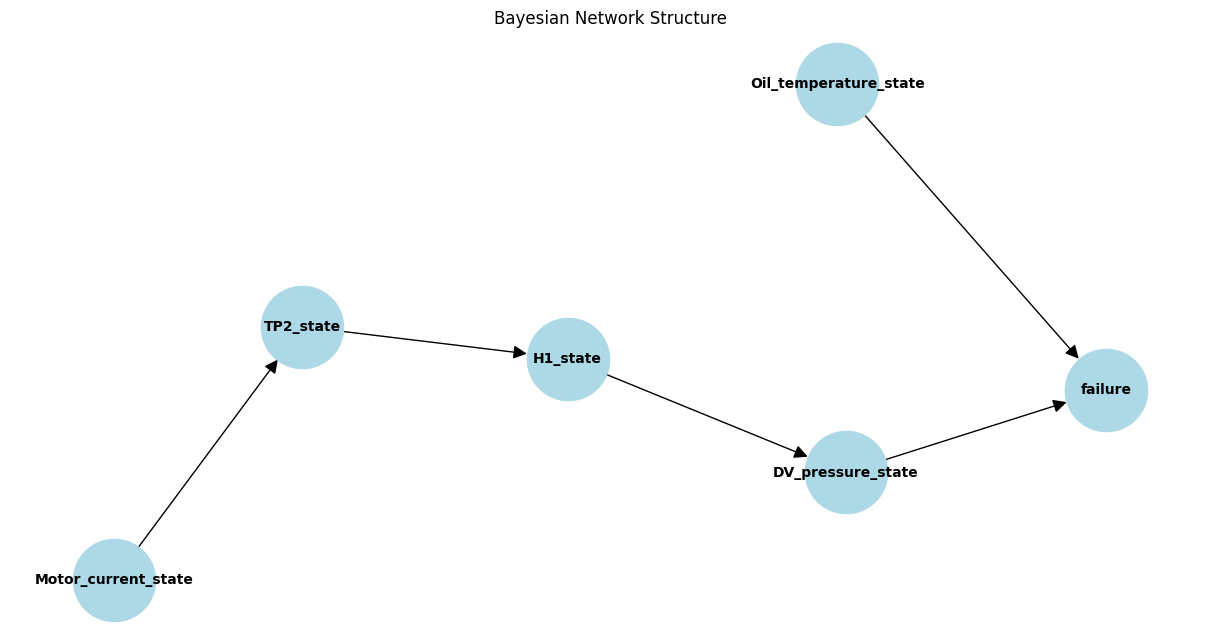

In [10]:
import networkx as nx

G = nx.DiGraph()
G.add_edges_from(model.edges())

plt.figure(figsize=(12, 6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    arrows=True,
    arrowsize=20
)

plt.title("Bayesian Network Structure")
plt.axis("off")
plt.show()

In [13]:
# Initialize Maximum Likelihood Estimator
mle = MaximumLikelihoodEstimator(
    model=model,
    data=bn_model_df
)

# Learn the CPDs
cpds = mle.get_parameters()

# Add CPDs to the model
model.add_cpds(*cpds)

print("Bayesian Network parameters learned successfully.")
print("Number of learned CPDs:", len(model.get_cpds()))

Bayesian Network parameters learned successfully.
Number of learned CPDs: 6


C:\Users\medam\AppData\Local\Temp\ipykernel_17240\7687634.py:2: FutureWarning: `pgmpy.estimators.MaximumLikelihoodEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteMLE` instead.
  mle = MaximumLikelihoodEstimator(


In [14]:
print("Checking Bayesian Network validity...")

print("Model valid:", model.check_model())

print("\nLearned CPDs:")
for cpd in model.get_cpds():
    print("\n", cpd)

Checking Bayesian Network validity...
Model valid: True

Learned CPDs:

 +-----------------------------+----------+
| Motor_current_state(High)   | 0.561962 |
+-----------------------------+----------+
| Motor_current_state(Low)    | 0.282717 |
+-----------------------------+----------+
| Motor_current_state(Medium) | 0.155321 |
+-----------------------------+----------+

 +---------------------+-----+-----------------------------+
| Motor_current_state | ... | Motor_current_state(Medium) |
+---------------------+-----+-----------------------------+
| TP2_state(High)     | ... | 0.000322407307898979        |
+---------------------+-----+-----------------------------+
| TP2_state(Low)      | ... | 0.9639978506179473          |
+---------------------+-----+-----------------------------+
| TP2_state(Medium)   | ... | 0.035679742074153684        |
+---------------------+-----+-----------------------------+

 +------------------+-----+---------------------+
| TP2_state        | ... | TP2_st

In [15]:
failure_cpd = model.get_cpds("failure")

print("Failure CPD:")
print(failure_cpd)

Failure CPD:
+-----------------------+-----+-------------------------------+
| DV_pressure_state     | ... | DV_pressure_state(Medium)     |
+-----------------------+-----+-------------------------------+
| Oil_temperature_state | ... | Oil_temperature_state(Medium) |
+-----------------------+-----+-------------------------------+
| failure(Failure)      | ... | 0.6744186046511628            |
+-----------------------+-----+-------------------------------+
| failure(Normal)       | ... | 0.32558139534883723           |
+-----------------------+-----+-------------------------------+


In [16]:
failure_cpd_table = failure_cpd.get_values()

print("CPD shape:", failure_cpd_table.shape)

print("\nProbability table:")
print(failure_cpd_table)

CPD shape: (2, 9)

Probability table:
[[0.99062804 0.         0.         0.36301821 0.0081717  0.
  0.96344946 0.72340426 0.6744186 ]
 [0.00937196 1.         1.         0.63698179 0.9918283  1.
  0.03655054 0.27659574 0.3255814 ]]


In [17]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

print("Bayesian inference engine created successfully.")

Bayesian inference engine created successfully.


In [18]:
result = inference.query(
    variables=["failure"],
    evidence={
        "DV_pressure_state": "High",
        "Oil_temperature_state": "High"
    }
)

print(result)

+------------------+----------------+
| failure          |   phi(failure) |
+==================+================+
| failure(Failure) |         0.9906 |
+------------------+----------------+
| failure(Normal)  |         0.0094 |
+------------------+----------------+


In [19]:
evidence_cases = [
    {
        "Case": "Low pressure, low temperature",
        "DV_pressure_state": "Low",
        "Oil_temperature_state": "Low"
    },
    {
        "Case": "Medium pressure, medium temperature",
        "DV_pressure_state": "Medium",
        "Oil_temperature_state": "Medium"
    },
    {
        "Case": "High pressure, high temperature",
        "DV_pressure_state": "High",
        "Oil_temperature_state": "High"
    },
    {
        "Case": "High pressure, medium temperature",
        "DV_pressure_state": "High",
        "Oil_temperature_state": "Medium"
    },
    {
        "Case": "Medium pressure, high temperature",
        "DV_pressure_state": "Medium",
        "Oil_temperature_state": "High"
    }
]

inference_results = []

for case in evidence_cases:
    result = inference.query(
        variables=["failure"],
        evidence={
            "DV_pressure_state": case["DV_pressure_state"],
            "Oil_temperature_state": case["Oil_temperature_state"]
        }
    )
    
    failure_probability = result.values[
        result.state_names["failure"].index("Failure")
    ]
    
    inference_results.append({
        "Case": case["Case"],
        "DV_pressure_state": case["DV_pressure_state"],
        "Oil_temperature_state": case["Oil_temperature_state"],
        "Failure_probability": failure_probability
    })

inference_df = pd.DataFrame(inference_results)

inference_df

,Case,DV_pressure_state,Oil_temperature_state,Failure_probability
0,"Low pressure, low temperature",Low,Low,0.008172
1,"Medium pressure, medium temperature",Medium,Medium,0.674419
2,"High pressure, high temperature",High,High,0.990628
3,"High pressure, medium temperature",High,Medium,0.000000
4,"Medium pressure, high temperature",Medium,High,0.963449


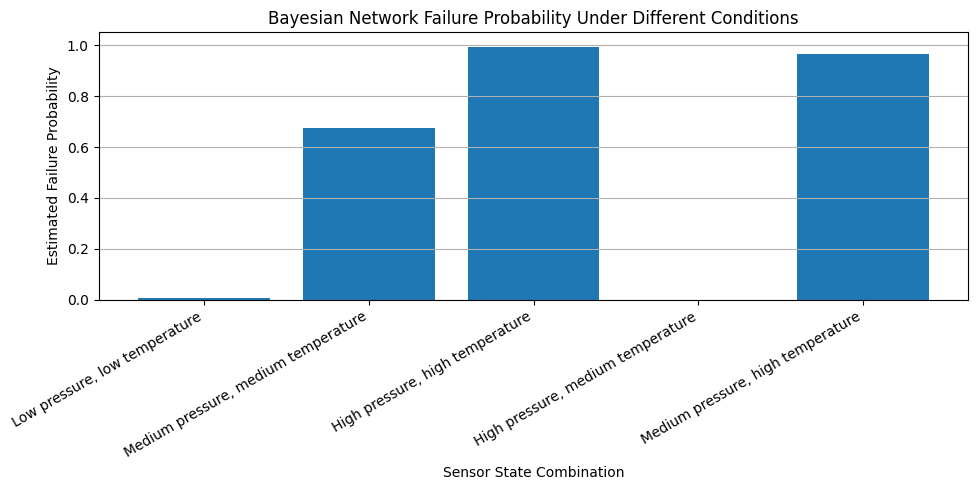

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    inference_df["Case"],
    inference_df["Failure_probability"]
)

plt.ylabel("Estimated Failure Probability")
plt.xlabel("Sensor State Combination")
plt.title("Bayesian Network Failure Probability Under Different Conditions")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [21]:
evidence = {
    "TP2_state": "High",
    "H1_state": "Low",
    "Motor_current_state": "High",
    "Oil_temperature_state": "High",
    "DV_pressure_state": "High"
}

result = inference.query(
    variables=["failure"],
    evidence=evidence
)

print("Evidence:")
for variable, state in evidence.items():
    print(f"{variable}: {state}")

print("\nBayesian Network inference:")
print(result)

Evidence:
TP2_state: High
H1_state: Low
Motor_current_state: High
Oil_temperature_state: High
DV_pressure_state: High

Bayesian Network inference:
+------------------+----------------+
| failure          |   phi(failure) |
+==================+================+
| failure(Failure) |         0.9906 |
+------------------+----------------+
| failure(Normal)  |         0.0094 |
+------------------+----------------+


In [22]:
evidence_cases = [
    {
        "Case": "Oil temperature only",
        "Evidence": {
            "Oil_temperature_state": "High"
        }
    },
    {
        "Case": "DV pressure only",
        "Evidence": {
            "DV_pressure_state": "High"
        }
    },
    {
        "Case": "DV pressure + oil temperature",
        "Evidence": {
            "DV_pressure_state": "High",
            "Oil_temperature_state": "High"
        }
    },
    {
        "Case": "All five sensors",
        "Evidence": {
            "TP2_state": "High",
            "H1_state": "Low",
            "Motor_current_state": "High",
            "Oil_temperature_state": "High",
            "DV_pressure_state": "High"
        }
    }
]

partial_inference_results = []

for case in evidence_cases:
    result = inference.query(
        variables=["failure"],
        evidence=case["Evidence"]
    )
    
    failure_probability = result.values[
        result.state_names["failure"].index("Failure")
    ]
    
    partial_inference_results.append({
        "Case": case["Case"],
        "Failure_probability": failure_probability
    })

partial_inference_df = pd.DataFrame(partial_inference_results)

print(partial_inference_df)

                            Case  Failure_probability
0           Oil temperature only             0.660664
1               DV pressure only             0.549783
2  DV pressure + oil temperature             0.990628
3               All five sensors             0.990628


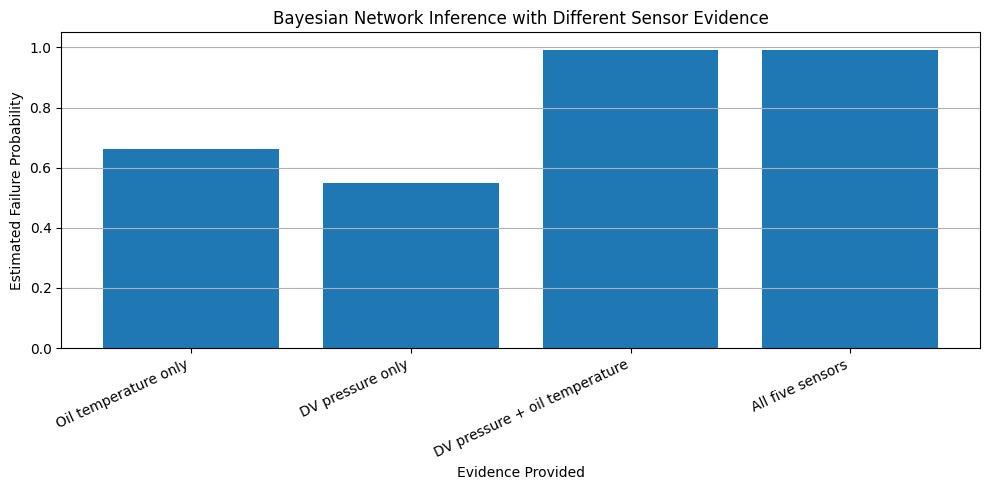

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    partial_inference_df["Case"],
    partial_inference_df["Failure_probability"]
)

plt.ylabel("Estimated Failure Probability")
plt.xlabel("Evidence Provided")
plt.title("Bayesian Network Inference with Different Sensor Evidence")

plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    
    r, k = table.shape
    phi2 = chi2 / n
    
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(
        phi2corr / min(kcorr - 1, rcorr - 1)
    )

association_matrix = pd.DataFrame(
    index=state_columns,
    columns=state_columns,
    dtype=float
)

for col1 in state_columns:
    for col2 in state_columns:
        association_matrix.loc[col1, col2] = cramers_v(
            bn_model_df[col1],
            bn_model_df[col2]
        )

print(association_matrix.round(3))


                       TP2_state  H1_state  Motor_current_state  \
TP2_state                  1.000     0.704                0.701   
H1_state                   0.704     1.000                0.841   
Motor_current_state        0.701     0.841                1.000   
Oil_temperature_state      0.575     0.604                0.627   
DV_pressure_state          0.646     0.594                0.593   

                       Oil_temperature_state  DV_pressure_state  
TP2_state                              0.575              0.646  
H1_state                               0.604              0.594  
Motor_current_state                    0.627              0.593  
Oil_temperature_state                  1.000              0.600  
DV_pressure_state                      0.600              1.000  


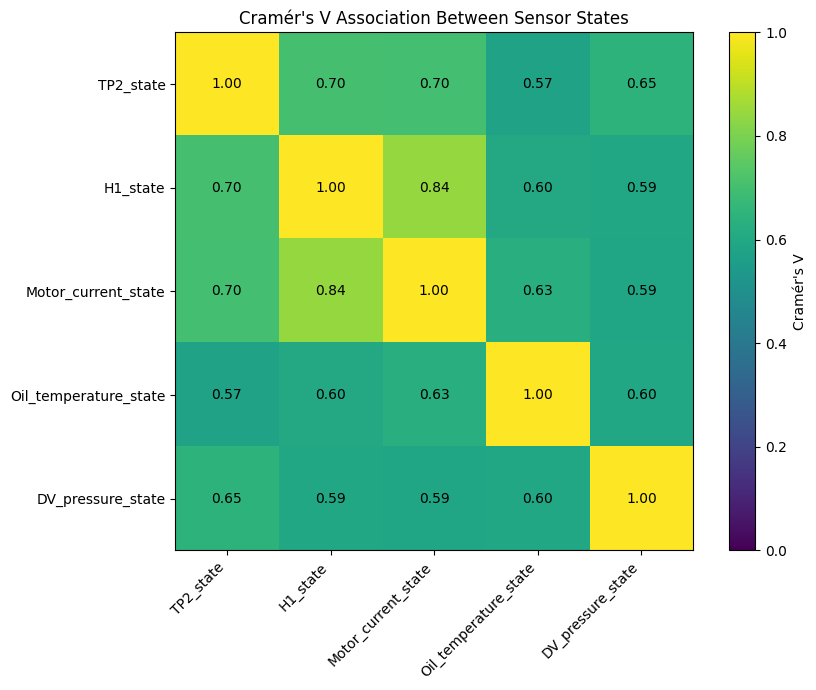

In [26]:
plt.figure(figsize=(9, 7))

plt.imshow(
    association_matrix.astype(float),
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Cramér's V")

plt.xticks(
    range(len(state_columns)),
    state_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(state_columns)),
    state_columns
)

# Add numerical values
for i in range(len(state_columns)):
    for j in range(len(state_columns)):
        plt.text(
            j,
            i,
            f"{association_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Cramér's V Association Between Sensor States")
plt.tight_layout()
plt.show()

In [27]:
print("Nodes:")
print(list(model.nodes()))

print("\nEdges:")
for edge in model.edges():
    print(f"{edge[0]} -> {edge[1]}")

Nodes:
['Motor_current_state', 'TP2_state', 'H1_state', 'DV_pressure_state', 'failure', 'Oil_temperature_state']

Edges:
Motor_current_state -> TP2_state
TP2_state -> H1_state
H1_state -> DV_pressure_state
DV_pressure_state -> failure
Oil_temperature_state -> failure


In [28]:
print("Conditional independencies implied by the Bayesian Network:\n")

independencies = model.get_independencies()

print(independencies)

Conditional independencies implied by the Bayesian Network:

(Oil_temperature_state ⟂ TP2_state)
(DV_pressure_state ⟂ TP2_state | H1_state)
(DV_pressure_state ⟂ Oil_temperature_state)
(Motor_current_state ⟂ failure | DV_pressure_state)
(DV_pressure_state ⟂ Motor_current_state | H1_state)
(H1_state ⟂ Oil_temperature_state)
(TP2_state ⟂ failure | DV_pressure_state)
(H1_state ⟂ failure | DV_pressure_state)
(Motor_current_state ⟂ Oil_temperature_state)
(H1_state ⟂ Motor_current_state | TP2_state)


In [29]:
from sklearn.model_selection import train_test_split

bn_train, bn_test = train_test_split(
    bn_model_df,
    test_size=0.20,
    random_state=42,
    stratify=bn_model_df["failure"]
)

print("BN training set:", bn_train.shape)
print("BN testing set:", bn_test.shape)

print("\nTraining class distribution:")
print(bn_train["failure"].value_counts())

print("\nTesting class distribution:")
print(bn_test["failure"].value_counts())

BN training set: (47926, 6)
BN testing set: (11982, 6)

Training class distribution:
failure
Failure    23963
Normal     23963
Name: count, dtype: int64

Testing class distribution:
failure
Normal     5991
Failure    5991
Name: count, dtype: int64


In [30]:
# Create a fresh BN with the same structure
eval_model = DiscreteBayesianNetwork([
    ("Motor_current_state", "TP2_state"),
    ("TP2_state", "H1_state"),
    ("H1_state", "DV_pressure_state"),
    ("DV_pressure_state", "failure"),
    ("Oil_temperature_state", "failure")
])

# Learn parameters from training data only
mle_eval = MaximumLikelihoodEstimator(
    model=eval_model,
    data=bn_train
)

eval_cpds = mle_eval.get_parameters()

eval_model.add_cpds(*eval_cpds)

print("Evaluation Bayesian Network trained successfully.")
print("Model valid:", eval_model.check_model())

Evaluation Bayesian Network trained successfully.
Model valid: True


C:\Users\medam\AppData\Local\Temp\ipykernel_17240\1852270418.py:11: FutureWarning: `pgmpy.estimators.MaximumLikelihoodEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteMLE` instead.
  mle_eval = MaximumLikelihoodEstimator(


In [31]:
eval_inference = VariableElimination(eval_model)

test_failure_probabilities = []

for _, row in bn_test.iterrows():
    evidence = {
        "TP2_state": row["TP2_state"],
        "H1_state": row["H1_state"],
        "Motor_current_state": row["Motor_current_state"],
        "Oil_temperature_state": row["Oil_temperature_state"],
        "DV_pressure_state": row["DV_pressure_state"]
    }
    
    result = eval_inference.query(
        variables=["failure"],
        evidence=evidence
    )
    
    failure_prob = result.values[
        result.state_names["failure"].index("Failure")
    ]
    
    test_failure_probabilities.append(failure_prob)

bn_test_results = bn_test.copy()
bn_test_results["failure_probability"] = test_failure_probabilities

print("Generated probabilities for:", len(bn_test_results), "test observations")
print("\nFirst 10 predictions:")
print(
    bn_test_results[
        ["failure", "failure_probability"]
    ].head(10)
)

Generated probabilities for: 11982 test observations

First 10 predictions:
       failure  failure_probability
42278   Normal             0.008218
25257   Normal             0.008218
56626  Failure             0.990810
10929   Normal             0.000000
17504  Failure             0.962686
48264   Normal             0.000000
26229   Normal             0.962686
7931    Normal             0.360713
46648   Normal             0.008218
47368  Failure             0.990810


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Convert actual labels to binary values
y_bn_test = (
    bn_test_results["failure"] == "Failure"
).astype(int)

# Convert probabilities to binary predictions
y_bn_pred = (
    bn_test_results["failure_probability"] >= 0.5
).astype(int)

# Calculate metrics
bn_accuracy = accuracy_score(y_bn_test, y_bn_pred)
bn_precision = precision_score(y_bn_test, y_bn_pred)
bn_recall = recall_score(y_bn_test, y_bn_pred)
bn_f1 = f1_score(y_bn_test, y_bn_pred)

print("Bayesian Network Performance")
print("----------------------------")
print(f"Accuracy : {bn_accuracy:.4f}")
print(f"Precision: {bn_precision:.4f}")
print(f"Recall   : {bn_recall:.4f}")
print(f"F1-score : {bn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_bn_test,
    y_bn_pred,
    target_names=["Normal", "Failure"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_bn_test, y_bn_pred))

Bayesian Network Performance
----------------------------
Accuracy : 0.9615
Precision: 0.9787
Recall   : 0.9436
F1-score : 0.9608

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.96      5991
     Failure       0.98      0.94      0.96      5991

    accuracy                           0.96     11982
   macro avg       0.96      0.96      0.96     11982
weighted avg       0.96      0.96      0.96     11982


Confusion Matrix:
[[5868  123]
 [ 338 5653]]


In [33]:
# Compare baseline ML models with the Bayesian Network

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Bayesian Network"
    ],
    "Accuracy": [
        0.982056,
        0.9960,
        bn_accuracy
    ],
    "Precision": [
        0.972204,
        0.9957,
        bn_precision
    ],
    "Recall": [
        0.992489,
        0.9963,
        bn_recall
    ],
    "F1-score": [
        0.982242,
        0.9960,
        bn_f1
    ]
})

print(comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.9821     0.9722  0.9925    0.9822
1        Random Forest    0.9960     0.9957  0.9963    0.9960
2     Bayesian Network    0.9615     0.9787  0.9436    0.9608
